In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

import re
from wordcloud import WordCloud

In [3]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AB\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\AB\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\AB\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
df = pd.read_csv(r"C:\Users\AB\Downloads\archive (17)\Hotel_Reviews.csv")

In [5]:
print(df.head())

                                       Hotel_Address  \
0   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
1   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
2   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
3   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
4   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   

   Additional_Number_of_Scoring Review_Date  Average_Score   Hotel_Name  \
0                           194    8/3/2017            7.7  Hotel Arena   
1                           194    8/3/2017            7.7  Hotel Arena   
2                           194   7/31/2017            7.7  Hotel Arena   
3                           194   7/31/2017            7.7  Hotel Arena   
4                           194   7/24/2017            7.7  Hotel Arena   

  Reviewer_Nationality                                    Negative_Review  \
0              Russia    I am so angry that i made this post available...   
1             Ireland                                     

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  object 
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  object 
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  object 
 5   Reviewer_Nationality                        515738 non-null  object 
 6   Negative_Review                             515738 non-null  object 
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  object 
 

In [7]:
print(df.columns)

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='object')


In [12]:
df["Clean_Review"] = df["Positive_Review"].apply(clean_text)

print(df[["Positive_Review", "Clean_Review"]].head())

                                     Positive_Review  \
0   Only the park outside of the hotel was beauti...   
1   No real complaints the hotel was great great ...   
2   Location was good and staff were ok It is cut...   
3   Great location in nice surroundings the bar a...   
4    Amazing location and building Romantic setting    

                                        Clean_Review  
0   only the park outside of the hotel was beauti...  
1   no real complaints the hotel was great great ...  
2   location was good and staff were ok it is cut...  
3   great location in nice surroundings the bar a...  
4    amazing location and building romantic setting   


In [15]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(review):

    score = sia.polarity_scores(review)

    if score['compound'] >= 0.05:
        return "Positive"

    elif score['compound'] <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Review"].apply(get_sentiment)

print(df["Sentiment"].value_counts())

Sentiment
Positive    432476
Neutral      76321
Negative      6941
Name: count, dtype: int64


In [18]:
def satisfaction(rating):

    if rating >= 4:
        return "Satisfied"

    elif rating == 3:
        return "Average"

    else:
        return "Unsatisfied"
    
df["Customer_Satisfaction"] = df["Reviewer_Score"].apply(satisfaction)

print(df["Customer_Satisfaction"].value_counts())

Customer_Satisfaction
Satisfied      505010
Unsatisfied     10691
Average            37
Name: count, dtype: int64


In [19]:
issues = {
    "Room":["room","bed","bathroom","noise"],
    "Staff":["staff","reception","manager","service"],
    "Cleanliness":["clean","dirty","smell"],
    "Food":["food","breakfast","restaurant","dinner"],
    "Amenities":["wifi","pool","parking","gym","spa"]
}

def identify_issue(review):

    review = review.lower()

    result = []

    for category, keywords in issues.items():

        for word in keywords:

            if word in review:

                result.append(category)

                break

    if len(result)==0:
        return "Other"

    return ", ".join(result)

df["Issue"] = df["Clean_Review"].apply(identify_issue)

print(df["Issue"].value_counts())

Issue
Other                                        156682
Staff                                         78300
Room                                          53129
Room, Staff                                   37812
Food                                          26518
Staff, Food                                   23276
Room, Staff, Food                             18041
Room, Staff, Cleanliness                      14774
Room, Cleanliness                             14126
Room, Food                                    14012
Cleanliness                                   10036
Staff, Cleanliness                             9062
Room, Amenities                                8213
Room, Staff, Cleanliness, Food                 7195
Room, Staff, Amenities                         5843
Amenities                                      5655
Room, Cleanliness, Food                        4265
Room, Staff, Food, Amenities                   3918
Room, Staff, Cleanliness, Amenities            3111
Room, 

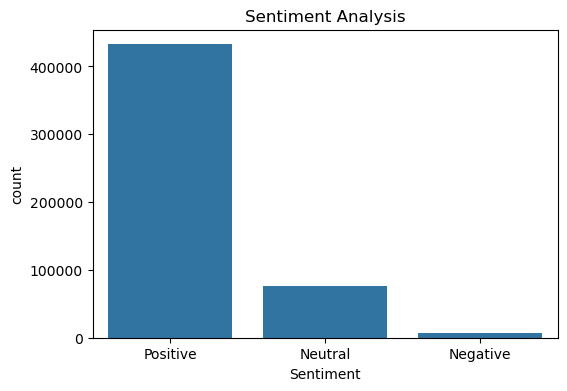

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Sentiment")

plt.title("Sentiment Analysis")

plt.show()

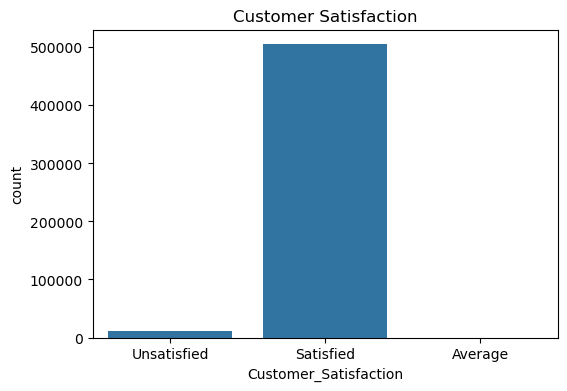

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Customer_Satisfaction")

plt.title("Customer Satisfaction")

plt.show()

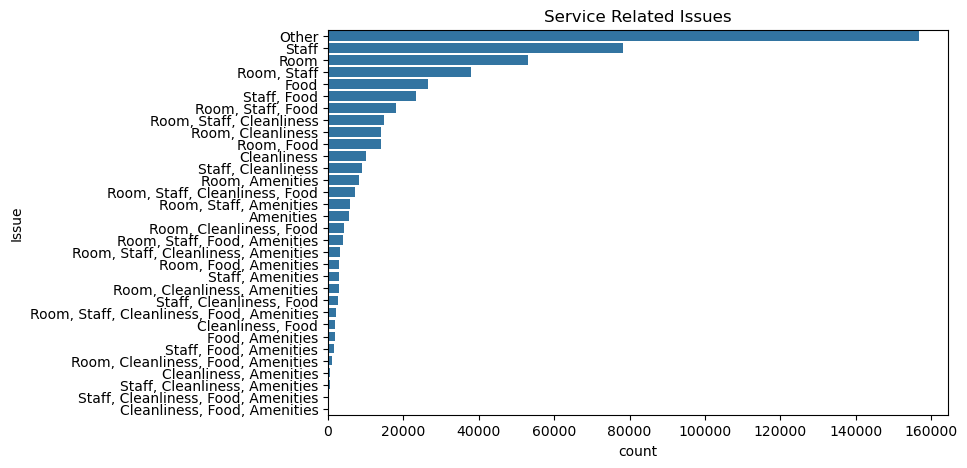

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,y="Issue",
              order=df["Issue"].value_counts().index)

plt.title("Service Related Issues")

plt.show()

In [23]:
print("Sentiment Report")

print(df["Sentiment"].value_counts())

print()

print("Customer Satisfaction")

print(df["Customer_Satisfaction"].value_counts())

print()

print("Service Issues")

print(df["Issue"].value_counts())

Sentiment Report
Sentiment
Positive    432476
Neutral      76321
Negative      6941
Name: count, dtype: int64

Customer Satisfaction
Customer_Satisfaction
Satisfied      505010
Unsatisfied     10691
Average            37
Name: count, dtype: int64

Service Issues
Issue
Other                                        156682
Staff                                         78300
Room                                          53129
Room, Staff                                   37812
Food                                          26518
Staff, Food                                   23276
Room, Staff, Food                             18041
Room, Staff, Cleanliness                      14774
Room, Cleanliness                             14126
Room, Food                                    14012
Cleanliness                                   10036
Staff, Cleanliness                             9062
Room, Amenities                                8213
Room, Staff, Cleanliness, Food                 7195
Roo